# 🧠 Amazon Sentiment Analysis — V2A
## Word2Vec (trained on my local data) + LSTM

**What this notebook does:**
- Trains Word2Vec FROM SCRATCH on my 1053 Amazon reviews
- Loads those vectors into Keras Embedding layer
- Trains LSTM for sentiment classification

**Difference from V1:**
- V1: TF-IDF (word counts) + Logistic Regression (line)
- V2A: Word2Vec (word meaning) + LSTM (sequence memory)

**Pipeline:**
```
Raw Text → clean_text() → Tokenizer → Word2Vec Embedding → LSTM → Positive/Negative
```


In [2]:
##Required libraries

## For data Handling
import pandas as pd
import numpy as np

## For visualization
import matplotlib.pyplot as plt
import seaborn as sns

## To remove words (clean text)
import re
import nltk

import warnings
warnings.filterwarnings('ignore')

##Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

##Importing Word2Vec model
from gensim.models import Word2Vec

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

**Declaring paths and variables

In [3]:
import os
os.chdir(r'D:\AMAZON_REVIEW_SENTIMENT')

DATA_PATH      = '/AMAZON_REVIEW_SENTIMENT/data/raw/amazon_review_dataset.csv'
REVIEW_COL     = 'reviews.text'      # column name for review text
RATING_COL  = 'reviews.rating'   # column name for label

# ── Word2Vec Settings ─────────────────────────────────────
W2V_VECTOR_SIZE = 100    # each word = 100 numbers
W2V_WINDOW      = 5      # look 5 words left and right
W2V_MIN_COUNT   = 1      # include words appearing >= 1 time
W2V_EPOCHS      = 50     # train Word2Vec for 50 passes
W2V_SG          = 1      # 1 = Skip-gram, 0 = CBOW

# ── LSTM Settings ─────────────────────────────────────────
MAX_WORDS   = 10000  # vocabulary size
MAX_LEN     = 100    # max words per review (pad/truncate)
LSTM_UNITS  = 64     # memory cells in LSTM
EPOCHS      = 15     # max training epochs
BATCH_SIZE  = 16     # small batch because dataset is small

# ══════════════════════════════════════════════════════════
print("✅ Settings loaded")
print(f"   Working directory: {os.getcwd()}")
print(f"   Word2Vec: {W2V_VECTOR_SIZE}d vectors, window={W2V_WINDOW}, skip-gram={bool(W2V_SG)}")
print(f"   LSTM: max_len={MAX_LEN}, units={LSTM_UNITS}, batch={BATCH_SIZE}")

✅ Settings loaded
   Working directory: D:\AMAZON_REVIEW_SENTIMENT
   Word2Vec: 100d vectors, window=5, skip-gram=True
   LSTM: max_len=100, units=64, batch=16


In [4]:
#Reading the raw data
df = pd.read_csv(DATA_PATH)
df.head(3)

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams


In [5]:
print("Columns : ",df.columns.tolist())

Columns :  ['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']


In [6]:
df.shape

(1597, 27)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

* data type is ok for only needed columns which is reviews.text and reviews.rating

In [8]:
df.describe()

,ean,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince,sizes,upc
count,8.980000e+02,900.000000,1177.000000,0.0,0.0,0.0,8.980000e+02
mean,8.443135e+11,83.584444,4.359388,NaN,NaN,NaN,8.443135e+11
std,3.416444e+09,197.150238,1.021445,NaN,NaN,NaN,3.416444e+09
min,8.416670e+11,0.000000,1.000000,NaN,NaN,NaN,8.416670e+11
25%,8.416670e+11,0.000000,4.000000,NaN,NaN,NaN,8.416670e+11
50%,8.416670e+11,0.000000,5.000000,NaN,NaN,NaN,8.416670e+11
75%,8.487190e+11,34.000000,5.000000,NaN,NaN,NaN,8.487190e+11
max,8.487190e+11,997.000000,5.000000,NaN,NaN,NaN,8.487190e+11


In [9]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

In [10]:
## Checking missing value
df.isnull().sum()

id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64

In [11]:
##dropping missing review rating
df = df.dropna(subset=[RATING_COL])
df.isnull().sum()

id                         0
asins                      0
brand                      0
categories                 0
colors                   508
dateAdded                  0
dateUpdated                0
dimension                620
ean                      484
keys                       0
manufacturer             451
manufacturerNumber       479
name                       0
prices                     0
reviews.date             217
reviews.doRecommend      638
reviews.numHelpful       277
reviews.rating             0
reviews.sourceURLs         0
reviews.text               0
reviews.title              0
reviews.userCity        1177
reviews.userProvince    1177
reviews.username           0
sizes                   1177
upc                      484
weight                   525
dtype: int64

In [12]:
df.shape

(1177, 27)

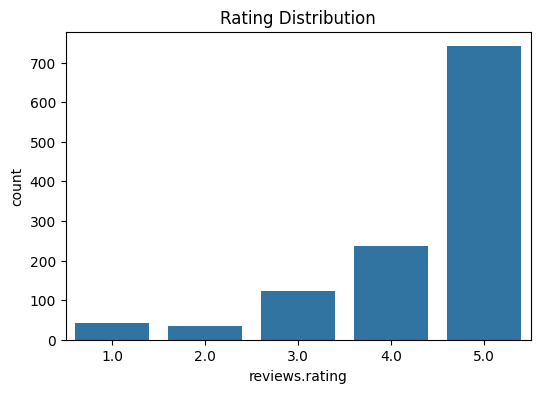

In [13]:
## Checking rating value by diagram
plt.figure(figsize=(6,4))
sns.countplot(x=RATING_COL, data=df)
plt.title("Rating Distribution")
plt.show()

In [14]:
# Check rating values 
print("Rating distribution:")
print(df[RATING_COL].value_counts().sort_index())
print()

Rating distribution:
reviews.rating
1.0     42
2.0     34
3.0    124
4.0    236
5.0    741
Name: count, dtype: int64



In [15]:
df = df[[REVIEW_COL, RATING_COL]]


In [16]:
df

,reviews.text,reviews.rating
0,I initially had trouble deciding between the p...,5.0
1,Allow me to preface this with a little history...,5.0
2,I am enjoying it so far. Great for reading. Ha...,4.0
3,I bought one of the first Paperwhites and have...,5.0
4,I have to say upfront - I don't like coroporat...,5.0
...,...,...
1592,This is not the same remote that I got for my ...,3.0
1593,I have had to change the batteries in this rem...,1.0
1594,"Remote did not activate, nor did it connect to...",1.0
1595,It does the job but is super over priced. I fe...,3.0


In [17]:
df.shape

(1177, 2)

In [18]:
##defining a function for converting in sentiment label
def label_sentiment(rating):
    if rating >= 4:
        return 1   # Positive
    elif rating <= 2:
        return 0   # Negative
    else:
        return None  # Neutral (we drop these)

df["sentiment"] = df[RATING_COL].apply(label_sentiment)

In [19]:
##Remove neutral review
df = df.dropna(subset=["sentiment"])
df["sentiment"].value_counts()

sentiment
1.0    977
0.0     76
Name: count, dtype: int64

** OBSERVATION: Dataset is highly imbalanced where
- Positive reviews : 977  (92.8%)
- Negative reviews : 76   (7.2%)

- Problem:  If we train model directly on this data,
- model will be biased towards positive class
- and will fail to detect negative reviews correctly

** Solution: 
- We will apply class_weight during LSTM training
  to handle this imbalance
- Negative class gets higher weight (≈6.90)
- Positive class gets lower weight (≈0.54)
- Each negative review counts as 6.90 reviews
- Forces LSTM to pay more attention to negatives
- NO SMOTE needed for deep learning
  (class_weight handles imbalance directly
   inside Keras model.fit())

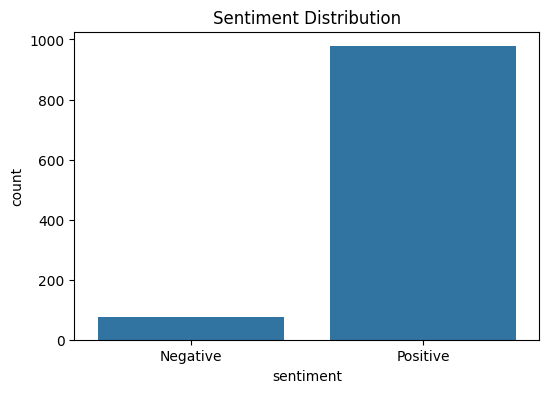

In [20]:
##Analyzing Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Sentiment Distribution")
plt.show()

In [21]:
##REview Length analysis
df["review_length"] = df[REVIEW_COL].apply(len)
df["review_length"].describe()

count     1053.000000
mean       697.446344
std       1307.149798
min          3.000000
25%        106.000000
50%        262.000000
75%       1343.000000
max      19739.000000
Name: review_length, dtype: float64

In [22]:
# Find the outlier review
long_review = df[df["review_length"] == df["review_length"].max()]
print(long_review["reviews.text"].values[0][:500])
# Just print first 500 chars to see what it looks like

I am not a casual user of on-demand content and devices. Having tried smart tv's from 3 brands, smart dvd/bluray players, Apple TV, WDTV, HTPC, Chromecast and too many other competing products to mention--for streaming content, before this box you really had two options (for a simple to use box that doesn't require additional items or tweaking):First is Apple TV which is easy to use (interface) but Apple limits the content you can get greatly (including no Prime Streaming built in) and it lacks 


In [23]:
# How many reviews are above 3000 characters
print(df[df["review_length"] > 3000].shape[0])
print(df[df["review_length"] > 5000].shape[0])

10
6


#### Review Length Analysis

- Mean: 697 chars, Max: 19,739 chars
- High max is expected — Amazon tech reviewers
- often write detailed comparison essays
- Wide std (1307) reflects natural variation
- from "Great!" to full product comparisons
- No outlier removal needed

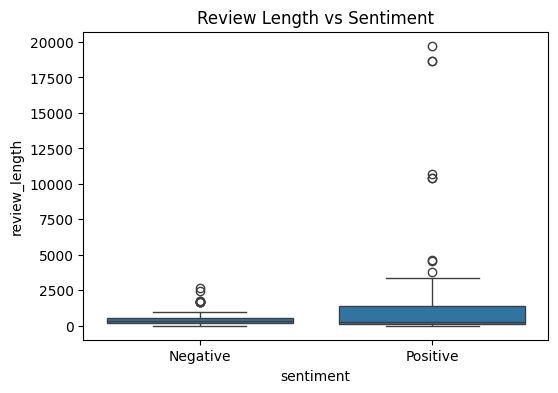

In [24]:
## Analyzing REview length vs Sentiment
plt.figure(figsize=(6,4))
sns.boxplot(x="sentiment", y="review_length", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Review Length vs Sentiment")
plt.show()

In [25]:
##Define a function for cleaning text
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'<.*?>', '', text)     # remove URLs
  text = re.sub(r'[^a-zA-Z\s]', '', text)   # keep only letters
  text = re.sub(r'\s+', ' ', text).strip()   # extra spaces   
  
  return text


df["Cleaned_Review"]=df["reviews.text"].apply(clean_text)
df = df.dropna(subset=["Cleaned_Review"])
df = df[df["Cleaned_Review"].str.strip() != ""]

In [26]:
df.head()

,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,i initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,i am enjoying it so far great for reading had ...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,i bought one of the first paperwhites and have...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,i have to say upfront i dont like coroporate h...


In [27]:
df.shape

(1053, 5)

*** Positive box is higher and wider so it means people usally write more when giving positive feedback and while Most negative reviews are concentrated near the bottom so suggests people often write short complaints

In [28]:
df[REVIEW_COL][0]

"I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both models now have 300 ppi, so the 80 dollar jump turns out pricey the voyage's page press isn't always sensitive, and if you are fine with a specific setting, you don't need auto light adjustment).It's been a week and I am loving my paperwhite, no regrets! The touch screen is receptive and easy to use, and I keep the light at a specific setting regardless of the time of day. (In any case, it's not hard to change the setting either, as you'll only be changing the light level at a certain time of day, not every now and then while reading).Also glad that I went for the international shipping option with Amazon. Extra expense, but delivery was on time, with tracking, and I didnt need to worry about cu

In [29]:
df["Cleaned_Review"][0]

'i initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing the paperwhite is great but if you have spending money go for the voyagefortunately i had friends who owned each so i ended up buying the paperwhite on this basis both models now have ppi so the dollar jump turns out pricey the voyages page press isnt always sensitive and if you are fine with a specific setting you dont need auto light adjustmentits been a week and i am loving my paperwhite no regrets the touch screen is receptive and easy to use and i keep the light at a specific setting regardless of the time of day in any case its not hard to change the setting either as youll only be changing the light level at a certain time of day not every now and then while readingalso glad that i went for the international shipping option with amazon extra expense but delivery was on time with tracking and i didnt need to worry about customs which i may have if i used a thir

In [30]:
#Saving the cleaned data
df.to_csv("\AMAZON_REVIEW_SENTIMENT/data/processed/cleaned_data_V2.csv", index=False)

### Feature Engineering

In [31]:
## Reading Cleaned data
import pandas as pd

df = pd.read_csv(
    "\AMAZON_REVIEW_SENTIMENT\data\processed\cleaned_data_V2.csv"
)

df.head()


,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,i initially had trouble deciding between the p...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow me to preface this with a little history...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,i am enjoying it so far great for reading had ...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,i bought one of the first paperwhites and have...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,i have to say upfront i dont like coroporate h...


In [32]:
##Selecting Input Column and Output Column
X=df["Cleaned_Review"]
y=df["sentiment"]

In [33]:
X

0       i initially had trouble deciding between the p...
1       allow me to preface this with a little history...
2       i am enjoying it so far great for reading had ...
3       i bought one of the first paperwhites and have...
4       i have to say upfront i dont like coroporate h...
                              ...                        
1048    voice remote gave out nearly a year after i pu...
1049    purchased my first one with the tv fire box ov...
1050    i have had to change the batteries in this rem...
1051    remote did not activate nor did it connect to ...
1052    i ordered this item to replace the one that no...
Name: Cleaned_Review, Length: 1053, dtype: object

In [34]:
y

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1048    0.0
1049    0.0
1050    0.0
1051    0.0
1052    0.0
Name: sentiment, Length: 1053, dtype: float64

In [35]:
##Splitting data into training and testing
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)


print("✅ Train/Test split complete")
print(f"   Train size:      {len(X_train)} reviews")
print(f"   Test size:       {len(X_test)} reviews")
print(f"   Train positives: {sum(y_train == 1)}")
print(f"   Train negatives: {sum(y_train == 0)}")
print(f"   Test positives:  {sum(y_test == 1)}")
print(f"   Test negatives:  {sum(y_test == 0)}")

✅ Train/Test split complete
   Train size:      842 reviews
   Test size:       211 reviews
   Train positives: 781
   Train negatives: 61
   Test positives:  196
   Test negatives:  15


In [36]:
##Converting text into number using Word2vec to understand for ML model
# Build vocabulary from TRAIN data only (never test)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text → number sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad all sequences to same length (MAX_LEN)
# padding='post' → zeros added at the END
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1

print("✅ Tokenization complete")
print(f"   Vocabulary size:      {vocab_size} unique words")
print(f"   X_train_pad shape:    {X_train_pad.shape}")
print(f"   X_test_pad shape:     {X_test_pad.shape}")
print()
print("Example conversion:")
print(f"   Text:    {X_train[0][:60]}...")
print(f"   Indices: {X_train_pad[0][:20]}...")

✅ Tokenization complete
   Vocabulary size:      5542 unique words
   X_train_pad shape:    (842, 100)
   X_test_pad shape:     (211, 100)

Example conversion:
   Text:    i initially had trouble deciding between the paperwhite and ...
   Indices: [  35  674 1070    3  152   16   50   34   11   77    6  674  564   11
  312 1837   12  107    5    2]...


** ---
##### Train Word2Vec on YOUR Amazon Reviews

**What happens here:**
```
Word2Vec reads our 1053 reviews
Slides a window of 5 words
Learns: which words appear near which words
Output: each word gets a 100-number vector

This is trained on our data
```

In [37]:
# Word2Vec needs tokenized sentences (list of word lists)
# NOT padded numbers — actual words

# Prepare sentences for Word2Vec training
# Split each cleaned review into list of words
w2v_sentences_train = [review.split() for review in X_train]
w2v_sentences_all   = [review.split() for review in X]  # train on ALL data for better vectors

print("Example sentence for Word2Vec:")
print(w2v_sentences_train[0][:10], "...")
print()

# Train Word2Vec ─

w2v_model = Word2Vec(
    sentences=w2v_sentences_all,  # all 1053 reviews
    vector_size=W2V_VECTOR_SIZE,  # 100-dimensional vectors
    window=W2V_WINDOW,            # look 5 words left/right
    min_count=W2V_MIN_COUNT,      # include all words
    sg=W2V_SG,                    # 1=Skip-gram (better for small data)
    epochs=W2V_EPOCHS,            # 50 passes over data
    workers=4,                    # parallel threads
    seed=42
)

print("✅ Word2Vec trained")
print(f"   Vocabulary: {len(w2v_model.wv)} words")
print(f"   Vector size: {W2V_VECTOR_SIZE} dimensions")
print()

# Test for checking similar words
print("Similarity test — words similar to Example 'good':")
try:
    similar = w2v_model.wv.most_similar('good', topn=5)
    for word, score in similar:
        print(f"   {word}: {score:.3f}")
except:
    print(" 'good' not in vocabulary — try another word")


Example sentence for Word2Vec:
['great', 'additional', 'piece', 'to', 'go', 'with', 'echo', 'if', 'you', 'want'] ...

✅ Word2Vec trained
   Vocabulary: 6009 words
   Vector size: 100 dimensions

Similarity test — words similar to Example 'good':
   lows: 0.553
   okdef: 0.530
   greatoverall: 0.522
   sound: 0.519
   buggyoperating: 0.514


---
#### Build Embedding Matrix from Word2Vec

**What this does:**
```
Your Tokenizer assigned index numbers to words
Word2Vec trained vectors for words

Now we need to connect them:
Word index 1 (amazing) → Word2Vec vector for 'amazing'
Word index 2 (good)    → Word2Vec vector for 'good'

This is the Embedding Matrix
Shape: (vocabulary_size, 100)

In [42]:
# Build embedding matrix
# Row i = vector for word at index i in tokenizer

embedding_matrix_w2v = np.zeros((MAX_WORDS, W2V_VECTOR_SIZE))

found     = 0
not_found = 0

for word, idx in tokenizer.word_index.items():
    if idx < MAX_WORDS:                        # only within vocabulary limit
        if word in w2v_model.wv:               # word exists in Word2Vec
            embedding_matrix_w2v[idx] = w2v_model.wv[word]
            found += 1
        else:
            not_found += 1                     # stays as zeros

print("✅ Word2Vec embedding matrix built")
print(f"   Matrix shape:          {embedding_matrix_w2v.shape}")
print(f"   Words found in W2V:    {found}")
print(f"   Words NOT in W2V:      {not_found}")
print()
print("What this means:")
print("   Row 0   = zeros (padding token)")
print("   Row 1   = vector for most common word")
print("   Row ... = vector for each word in our vocab")
print()
print(f"   Row for index 1: {embedding_matrix_w2v[1][:8]}...")

✅ Word2Vec embedding matrix built
   Matrix shape:          (10000, 100)
   Words found in W2V:    5540
   Words NOT in W2V:      1

What this means:
   Row 0   = zeros (padding token)
   Row 1   = vector for most common word
   Row ... = vector for each word in our vocab

   Row for index 1: [0. 0. 0. 0. 0. 0. 0. 0.]...


---
Build LSTM Model with Word2Vec Embedding

**Architecture:**
```
Input (100 word indices)
    ↓
Embedding Layer (Word2Vec vectors, frozen)
    ↓
Bidirectional LSTM (reads forward AND backward)
    ↓
Dropout (prevents overfitting)
    ↓
Dense sigmoid (probability 0-1)
    ↓
Positive / Negative
```

In [43]:
model_w2v = Sequential([

    #Layer 1: Embedding ─
    # Loads Word2Vec vectors
    # trainable=False → we keep our trained W2V vectors unchanged
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=W2V_VECTOR_SIZE,
        weights=[embedding_matrix_w2v],  # our Word2Vec matrix
        input_length=MAX_LEN,
        trainable=False                  # freeze — don't change W2V vectors
    ),

    #Layer 2: Bidirectional LSTM ─
    # Reads review FORWARD: "not bad at all"
    # AND BACKWARD:         "all at bad not"
    # Combines both → better understanding
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.3, recurrent_dropout=0.2)),

    #Layer 3: Dropout ─
    # Randomly turns off 50% neurons during training
    # Prevents memorizing training data
    Dropout(0.5),

    #Layer 4: Output ─
    # sigmoid: outputs probability between 0 and 1
    # > 0.5 → Positive, < 0.5 → Negative
    Dense(1, activation='sigmoid')
])

model_w2v.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Word2Vec + LSTM Model built")
model_w2v.summary()

✅ Word2Vec + LSTM Model built
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          1000000   
                                                                 
 bidirectional (Bidirection  (None, 128)               84480     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1084609 (4.14 MB)
Trainable params: 84609 (330.50 KB)
Non-trainable params: 1000000 (3.81 MB)
_________________________________________________________________


---
### Train the LSTM Model

In [44]:
# Callbacks ─
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,                  # stop if no improvement for 4 epochs
    restore_best_weights=True,   # use best weights, not last
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # halve learning rate when stuck
    patience=2,
    min_lr=1e-6,
    verbose=1
)

#Class weights for imbalance ─
# 977 positive vs 76 negative → weight negatives more
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
total     = len(y_train)
class_weight = {
    0: total / (2 * neg_count),  # negative gets higher weight
    1: total / (2 * pos_count)
}
print(f"Class weights: {class_weight}")
print()

#Train ─
print("Training Word2Vec + LSTM model...")

history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,          # 10% of train for validation
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print()
print("✅ Training complete")

Class weights: {0: 6.901639344262295, 1: 0.5390524967989757}

Training Word2Vec + LSTM model...
Epoch 1/15
48/48 [==============================] - 28s 203ms/step - loss: 0.6983 - accuracy: 0.6948 - val_loss: 0.6510 - val_accuracy: 0.5882 - lr: 0.0010
Epoch 2/15
48/48 [==============================] - 7s 150ms/step - loss: 0.6543 - accuracy: 0.5760 - val_loss: 0.6421 - val_accuracy: 0.6118 - lr: 0.0010
Epoch 3/15
48/48 [==============================] - 7s 155ms/step - loss: 0.5890 - accuracy: 0.6816 - val_loss: 0.8683 - val_accuracy: 0.4235 - lr: 0.0010
Epoch 4/15
48/48 [==============================] - 8s 162ms/step - loss: 0.5029 - accuracy: 0.7768 - val_loss: 0.2614 - val_accuracy: 0.9412 - lr: 0.0010
Epoch 5/15
48/48 [==============================] - 7s 140ms/step - loss: 0.4700 - accuracy: 0.7966 - val_loss: 0.6373 - val_accuracy: 0.6118 - lr: 0.0010
Epoch 6/15
48/48 [==============================] - ETA: 0s - loss: 0.3943 - accuracy: 0.8441
Epoch 6: ReduceLROnPlateau reducin

---
### Evaluate Word2Vec + LSTM

Word2Vec + LSTM Results:
   Test Accuracy: 0.9100 (91.00%)
   Test Loss:     0.2464

Classification Report:
              precision    recall  f1-score   support

    Negative       0.39      0.47      0.42        15
    Positive       0.96      0.94      0.95       196

    accuracy                           0.91       211
   macro avg       0.67      0.71      0.69       211
weighted avg       0.92      0.91      0.91       211



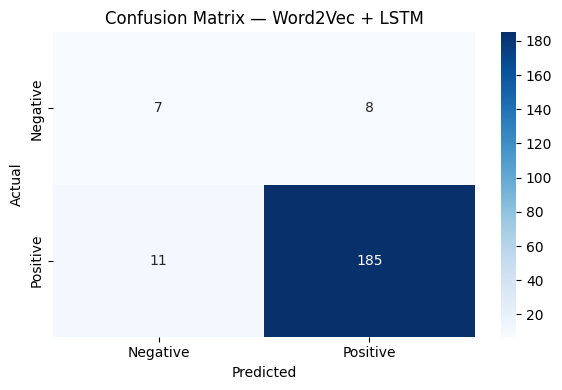

✅ Confusion matrix saved: confusion_matrix_w2v.png


In [45]:
# Test Accuracy ─
loss_w2v, acc_w2v = model_w2v.evaluate(X_test_pad, y_test, verbose=0)
print(f"Word2Vec + LSTM Results:")
print(f"   Test Accuracy: {acc_w2v:.4f} ({acc_w2v*100:.2f}%)")
print(f"   Test Loss:     {loss_w2v:.4f}")
print()

# Predictions ─
y_pred_prob_w2v = model_w2v.predict(X_test_pad, verbose=0)
y_pred_w2v      = (y_pred_prob_w2v > 0.5).astype(int).flatten()

# Classification Report ─
print("Classification Report:")
print(classification_report(
    y_test, y_pred_w2v,
    target_names=['Negative', 'Positive']
))

# ── Confusion Matrix ──────────────────────────────────────
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_w2v, annot=True, fmt='d',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cmap='Blues')
plt.title('Confusion Matrix — Word2Vec + LSTM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_w2v.png', dpi=100)
plt.show()
print("✅ Confusion matrix saved: confusion_matrix_w2v.png")

### 📈 — Training Curves

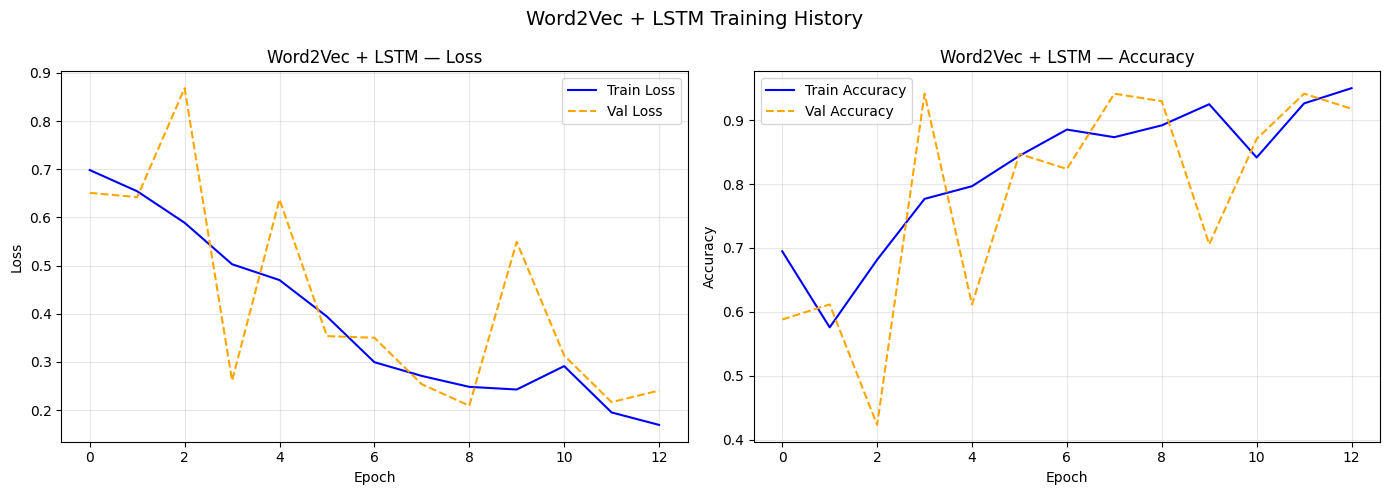

✅ Training curves saved: training_curves_w2v.png


In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(history_w2v.history['loss'],     label='Train Loss', color='blue')
ax1.plot(history_w2v.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
ax1.set_title('Word2Vec + LSTM — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(history_w2v.history['accuracy'],     label='Train Accuracy', color='blue')
ax2.plot(history_w2v.history['val_accuracy'], label='Val Accuracy',   color='orange', linestyle='--')
ax2.set_title('Word2Vec + LSTM — Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Word2Vec + LSTM Training History', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves_w2v.png', dpi=100)
plt.show()
print("✅ Training curves saved: training_curves_w2v.png")

---
### 💾 Save Word2Vec Model and LSTM

In [47]:
import pickle
os.makedirs('models_v2a_word2vec', exist_ok=True)

# Save Word2Vec model
w2v_model.save('models_v2a_word2vec/word2vec.model')

# Save LSTM model
model_w2v.save('models_v2a_word2vec/lstm_model.h5')

# Save Tokenizer
with open('models_v2a_word2vec/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# Save embedding matrix
np.save('models_v2a_word2vec/embedding_matrix.npy', embedding_matrix_w2v)

print("✅ All models saved:")
print("   models_v2a_word2vec/word2vec.model")
print("   models_v2a_word2vec/lstm_model.h5")
print("   models_v2a_word2vec/tokenizer.pkl")
print("   models_v2a_word2vec/embedding_matrix.npy")

✅ All models saved:
   models_v2a_word2vec/word2vec.model
   models_v2a_word2vec/lstm_model.h5
   models_v2a_word2vec/tokenizer.pkl
   models_v2a_word2vec/embedding_matrix.npy


---
### Test on V1 Failing Reviews  (ifidf + Logistic Regression)

In [48]:
def predict_w2v(review_text):
    """
    Predict sentiment using Word2Vec + LSTM model
    """
    clean   = clean_text(review_text)
    seq     = tokenizer.texts_to_sequences([clean])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob    = model_w2v.predict(padded, verbose=0)[0][0]
    label   = 'POSITIVE ✅' if prob > 0.5 else 'NEGATIVE ❌'
    return label, round(float(prob), 3)


# ── Reviews that FAILED in tfidf + LSTM model
test_reviews = [
    ("Not bad at all! Initially worried but exceeded expectations",
     "Should be POSITIVE — V1 failed (saw bad/worried)"),

    ("Packaging nice, delivery fast, but product useless, stopped working",
     "Should be NEGATIVE — V1 failed (distracted by nice/fast)"),

    ("Amazing quality, totally worth the money",
     "Should be POSITIVE — easy case"),

    ("Worst product ever, complete waste of money",
     "Should be NEGATIVE — easy case"),

    ("Not what I expected but surprisingly good",
     "Should be POSITIVE — tricky negation"),

    ("Good packaging but terrible quality inside",
     "Should be NEGATIVE — mixed review")
]

print("=" * 65)
print("WORD2VEC + LSTM PREDICTIONS")
print("=" * 65)

for review, note in test_reviews:
    label, prob = predict_w2v(review)
    print(f"\nReview: {review}")
    print(f"Note:   {note}")
    print(f"Result: {label} | Confidence: {prob}")

print()
print("=" * 65)

WORD2VEC + LSTM PREDICTIONS

Review: Not bad at all! Initially worried but exceeded expectations
Note:   Should be POSITIVE — V1 failed (saw bad/worried)
Result: POSITIVE ✅ | Confidence: 0.844

Review: Packaging nice, delivery fast, but product useless, stopped working
Note:   Should be NEGATIVE — V1 failed (distracted by nice/fast)
Result: NEGATIVE ❌ | Confidence: 0.338

Review: Amazing quality, totally worth the money
Note:   Should be POSITIVE — easy case
Result: POSITIVE ✅ | Confidence: 0.744

Review: Worst product ever, complete waste of money
Note:   Should be NEGATIVE — easy case
Result: NEGATIVE ❌ | Confidence: 0.452

Review: Not what I expected but surprisingly good
Note:   Should be POSITIVE — tricky negation
Result: NEGATIVE ❌ | Confidence: 0.426

Review: Good packaging but terrible quality inside
Note:   Should be NEGATIVE — mixed review
Result: POSITIVE ✅ | Confidence: 0.562



---
### 📋V1(TF-Idf + Logistic Regression) vs V2A (Word2Vec + LSTM) -- Comparison Summary

In [50]:
print("=" * 55)
print("COMPARISON: V1 vs V2A")
print("=" * 55)
print()
print("V1 — TF-IDF + Logistic Regression:")
print("   Accuracy:  92.41%")
print("   Neg F1:    0.38")
print("   Macro F1:  0.67")
print("   Weakness:  No word order, no context")
print()
print(f"V2A — Word2Vec + LSTM:")
print(f"   Accuracy:  {acc_w2v*100:.2f}%")
print(f"   (see classification report above for F1)")
print(f"   Strength:  Word meaning + sequence memory")
print(f"   Weakness:  Word2Vec trained on small data (1053 reviews)")
print()
print()
print("Next: V2B uses PRE-TRAINED GloVe")
print("      (trained on 6 BILLION words by Stanford)")
print("      Expected to perform better than V2A")
print("=" * 55)

COMPARISON: V1 vs V2A

V1 — TF-IDF + Logistic Regression:
   Accuracy:  92.41%
   Neg F1:    0.38
   Macro F1:  0.67
   Weakness:  No word order, no context

V2A — Word2Vec + LSTM:
   Accuracy:  91.00%
   (see classification report above for F1)
   Strength:  Word meaning + sequence memory
   Weakness:  Word2Vec trained on small data (1053 reviews)


Next: V2B uses PRE-TRAINED GloVe
      (trained on 6 BILLION words by Stanford)
      Expected to perform better than V2A
